2026-04-09 06:58:56.319647: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 06:58:56.353418: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775689136.381506   42589 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775689136.394296   42589 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-09 06:58:56.444452: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

>>> 正在加载环境和模型...
>>> 求解 PDE 基线...
>>> 加载 RL 模型...


/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn

>>> 开始 50 次平行宇宙的回测与数据收集...

🏆 真实规模的大比武战报:
理论极限 (PDE DP) 平均成本 : 29.4672
人工智能 (RL PPO) 平均成本 : 31.0641
效率比 (RL/PDE)           : 105.42% (越接近100%越完美)


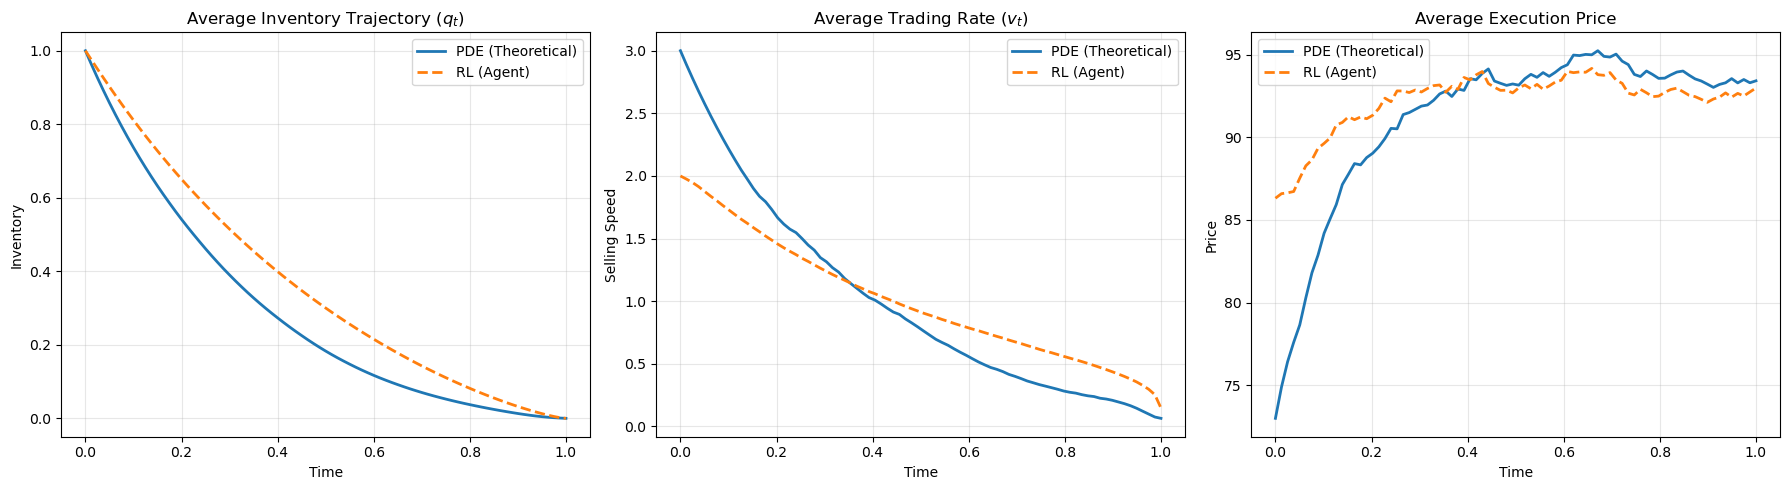

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from stable_baselines3 import PPO

sys.path.append(os.path.abspath('..'))
from Environment.liquidation_env import LiquidationEnv
from PDE_Baseline.nonlinear_ac_dp import ModelParams, GridParams, solve_dp, policy_at, permanent_impact, temporary_impact

print(">>> 正在加载环境和模型...")
shared_kwargs = {
    'T': 1.0, 'q0': 1.0, 'S0': 100.0, 'sigma': 0.20, 'lam': 0.5, 'alpha': 120.0,
    'gamma1': 2.0, 'gamma2': 1.5, 'eta1': 3.0, 'eta2': 2.0
}
pde_model = ModelParams(**shared_kwargs)
pde_grid = GridParams(Nt=80, Nq=80, NS=50, Nv=81)

print(">>> 求解 PDE 基线...")
pde_solution = solve_dp(pde_model, pde_grid, verbose=False)

print(">>> 加载 RL 模型...")
rl_model = PPO.load("../models/ppo_ultimate_baseline")
rl_env = LiquidationEnv(**shared_kwargs, N=80) 

# 用于存储 50 次回测的所有轨迹数据
num_tests = 50
rng = np.random.default_rng(2026)

pde_metrics = {'cost': [], 'q': [], 'v': [], 'price': []}
rl_metrics = {'cost': [], 'q': [], 'v': [], 'price': []}

print(f">>> 开始 {num_tests} 次平行宇宙的回测与数据收集...")

for i in range(num_tests):
    z_path = rng.normal(size=80)
    
    # ================= 运行 PDE =================
    m = pde_solution["model"]
    dt = pde_solution["dt"]
    q_pde = np.zeros(81); q_pde[0] = m.q0
    S_pde = np.zeros(81); S_pde[0] = m.S0
    v_pde = np.zeros(80)
    exec_price_pde = np.zeros(80)
    cost_pde = 0.0
    
    for n in range(80):
        v_pde[n] = min(policy_at(pde_solution, n, q_pde[n], S_pde[n]), q_pde[n] / dt)
        Qcum = m.q0 - q_pde[n]
        
        # 记录执行价格 (无冲击价格 - 永久冲击 - 临时冲击)
        exec_price_pde[n] = S_pde[n] - permanent_impact(Qcum, m) - temporary_impact(v_pde[n], m)
        
        cost_step = ((permanent_impact(Qcum, m) + temporary_impact(v_pde[n], m)) * v_pde[n] + 
                     0.5 * m.lam * m.sigma**2 * S_pde[n]**2 * q_pde[n]**2) * dt
        cost_pde += cost_step
        
        q_pde[n + 1] = max(0.0, q_pde[n] - v_pde[n] * dt)
        S_pde[n + 1] = S_pde[n] * np.exp((-0.5 * m.sigma**2) * dt + m.sigma * np.sqrt(dt) * z_path[n])
        
    cost_pde += 0.5 * m.alpha * S_pde[-1]**2 * q_pde[-1]**2
    
    pde_metrics['cost'].append(cost_pde)
    pde_metrics['q'].append(q_pde)
    pde_metrics['v'].append(v_pde)
    pde_metrics['price'].append(exec_price_pde)

    # ================= 运行 RL =================
    obs, _ = rl_env.reset(z_path=z_path)
    cost_rl = 0.0
    q_rl, v_rl, exec_price_rl = [rl_env.q0], [], []
    
    done = False
    while not done:
        action, _ = rl_model.predict(obs, deterministic=True)
        obs, reward, term, trunc, info = rl_env.step(action)
        
        # 修复 Bug：还原真实的 Cost
        cost_rl += -(reward / rl_env.reward_scale) 
        
        q_rl.append(info["inventory"])
        v_rl.append(info["execution_rate"])
        exec_price_rl.append(info["execution_price"])
        done = term or trunc
        
    rl_metrics['cost'].append(cost_rl)
    rl_metrics['q'].append(q_rl)
    rl_metrics['v'].append(v_rl)
    rl_metrics['price'].append(exec_price_rl)

# ================= 打印最终战报 =================
mean_pde_cost = np.mean(pde_metrics['cost'])
mean_rl_cost = np.mean(rl_metrics['cost'])

print("\n" + "="*50)
print("🏆 真实规模的大比武战报:")
print(f"理论极限 (PDE DP) 平均成本 : {mean_pde_cost:.4f}")
print(f"人工智能 (RL PPO) 平均成本 : {mean_rl_cost:.4f}")
print(f"效率比 (RL/PDE)           : {mean_rl_cost / mean_pde_cost * 100:.2f}% (越接近100%越完美)")
print("="*50)

# ================= 绘制平均轨迹对比图 =================
time_axis = np.linspace(0, 1.0, 81)
time_axis_v = np.linspace(0, 1.0, 80) # 速率和价格只有 80 步

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 图1: 平均库存轨迹
axs[0].plot(time_axis, np.mean(pde_metrics['q'], axis=0), label="PDE (Theoretical)", linewidth=2)
axs[0].plot(time_axis, np.mean(rl_metrics['q'], axis=0), label="RL (Agent)", linestyle='--', linewidth=2)
axs[0].set_title("Average Inventory Trajectory ($q_t$)")
axs[0].set_ylabel("Inventory")

# 图2: 平均交易速率
axs[1].plot(time_axis_v, np.mean(pde_metrics['v'], axis=0), label="PDE (Theoretical)", linewidth=2)
axs[1].plot(time_axis_v, np.mean(rl_metrics['v'], axis=0), label="RL (Agent)", linestyle='--', linewidth=2)
axs[1].set_title("Average Trading Rate ($v_t$)")
axs[1].set_ylabel("Selling Speed")

# 图3: 平均执行价格
axs[2].plot(time_axis_v, np.mean(pde_metrics['price'], axis=0), label="PDE (Theoretical)", linewidth=2)
axs[2].plot(time_axis_v, np.mean(rl_metrics['price'], axis=0), label="RL (Agent)", linestyle='--', linewidth=2)
axs[2].set_title("Average Execution Price")
axs[2].set_ylabel("Price")

for ax in axs:
    ax.set_xlabel("Time")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("detailed_showdown.png", dpi=300)
plt.show()